# REINFROCE

In this Lab, you will implement REINFORCE on cartpole environment 

https://gymnasium.farama.org/environments/classic_control/cart_pole/

In [176]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch.nn as nn
from dataclasses import dataclass
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.distributions import Categorical

## Let's start with the sampling trajectory function

In [177]:
def sample_n_trajectories(env: gym.Env, num_trajectories: int, actor, seed):
    
    trajectories = {}
    
    obs = []
    next_obs = []
    actions = []
    log_probs = []
    rewards = []
    terminals = []
    for _ in range(num_trajectories):
        trajectory = sample_trajectory(env, actor, seed)
        obs.append(trajectory['obs'])
        next_obs.append(trajectory['next_obs'])
        rewards.append(trajectory['rewards'])
        actions.append(trajectory['actions'])
        log_probs.append(trajectory['log_probs'])
        terminals.append(trajectory['terminals'])

    trajectories['obs'] = obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['next_obs'] = next_obs # list of length n, each element is a tensor of size (num_steps_per_trajectory, obs_dim)
    trajectories['actions'] = actions # list of length n, each element is a tensor of size (num_steps_per_trajectory, action_dim)
    trajectories['log_probs'] = log_probs # list of length n, each element is a tensor of size (num_steps_per_trajectory)
    trajectories['rewards'] = rewards # list of length n, each element is a tensor of size (num_steps_per_trajectory)
    trajectories['terminals'] = terminals # list of length n, each element is a tensor of size (num_steps_per_trajectory)

    return trajectories

    
    
def sample_trajectory(env: gym.Env, actor, seed):
    obs = []
    next_obs = []
    actions = []
    log_probs = []
    rewards = []
    terminals = []
    
    ob, _ = env.reset(seed=seed)
    while True:
#         action = env.action_space.sample()
        action, log_prob = actor.get_action(torch.FloatTensor(ob))
        next_ob, rew, terminated, truncated, info = env.step(action.cpu().numpy())
        rollout_done = terminated or truncated
        
        obs.append(torch.FloatTensor(ob))
        next_obs.append(torch.FloatTensor(next_ob))
        rewards.append(torch.tensor([rew], dtype=float))
        actions.append(torch.tensor([action], dtype=float))
        log_probs.append(log_prob)
        terminals.append(torch.tensor([rollout_done], dtype=bool))
        
        if rollout_done:
            break
        
        ob = next_ob
    
    trajectory = {}
    trajectory['obs'] = torch.stack(obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['next_obs'] = torch.stack(obs, dim=0) # (num_steps_per_trajectory, obs_dim)
    trajectory['rewards'] = torch.stack(rewards, dim=0).squeeze(1) # (num_steps_per_trajectory)
    trajectory['actions'] = torch.stack(actions, dim=0) # (num_steps_per_trajectory, action_dim)
    trajectory['log_probs'] = torch.stack(log_probs, dim=0) # (num_steps_per_trajectory)
    trajectory['terminals'] = torch.stack(terminals, dim=0).squeeze(1) # (num_steps_per_trajectory)
    
    return trajectory

In [178]:
@dataclass
class MLPConfig:
    n_in: int
    n_out: int
    n_hidden: int = 64
    n_layers: int = 2
    activation: str = 'relu'
    output_activation: str = 'identity'

In [179]:
@dataclass
class ReinforceAgentConfig:
    """Configuration for the ReinforceAgent.
    This class holds all the parameters needed to initialize the agent, including
    architecture, optimization parameters, and algorithm-specific settings.
    """
    ## architecture parameters 
    obs_dim: int = 4
    act_dim: int = 2
    n_hidden: int = 64
    n_layers: int = 2
    activation: str = 'relu'

    ## actor optimization parameters
    actor_lr: float = 1e-3
    actor_optimizer: str = 'adam'
    normalize_advantage: bool = True

    ## other parameters
    gamma: float = 1
    n_updates: int = 200
    n_trajectories = 100

In [180]:
_str_to_activation = {
    'relu': nn.ReLU(),
    'tanh': nn.Tanh(),
    'leaky_relu': nn.LeakyReLU(),
    'sigmoid': nn.Sigmoid(),
    'selu': nn.SELU(),
    'softplus': nn.Softplus(),
    'identity': nn.Identity(),
    'softmax': nn.Softmax(dim=-1)
}

## Now, let's code the REINFORCE Actor. 

We will use a feedforward NN as our policy-network. 


In [181]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        activation = _str_to_activation[config.activation]
        output_activation = _str_to_activation[config.output_activation]

        layers = []
        n_in = config.n_in
        for _ in range(config.n_layers):
            layers.append(nn.Linear(n_in, config.n_hidden))
            layers.append(activation)
            n_in = config.n_hidden
        layers.append(nn.Linear(config.n_hidden, config.n_out))
        layers.append(output_activation)

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [182]:
class ReinforceAgent(nn.Module):
    def __init__(self, config: ReinforceAgentConfig):
        """ Initializes the ReinforceAgent with the given configuration.
        Args:
            config (ReinforceAgentConfig): Configuration for the agent, including architecture, 
            optimization parameters, etc.
        """
        super().__init__()

        self.config = config
        
        self.actor, self.actor_optimizer = self._make_actor()
        
    def _make_actor(self):
        """ Creates the actor network based on the configuration.
        Returns:
            actor (nn.Module): The actor network.
            logstd (torch.nn.Parameter): Log standard deviation for continuous action spaces.
            actor_optimizer (torch.optim.Optimizer): Optimizer for the actor network.
            actor_lr_scheduler (torch.optim.lr_scheduler): Learning rate scheduler for the actor.
        """
        mlp_config = MLPConfig(*[self.config.obs_dim, self.config.act_dim,
                                 self.config.n_hidden, self.config.n_layers, 
                                 self.config.activation])
        
        actor = MLP(mlp_config)
        
        parameters = actor.parameters()
        
        actor_optimizer = optim.Adam(parameters, lr=self.config.actor_lr)

        return actor, actor_optimizer
    
    def get_action(self, obs: torch.Tensor) -> torch.Tensor:
        """ Computes the action to take given the observation.
        Args:
            obs (torch.Tensor): The observation from the environment, shape (batch_size, obs_dim).
        Returns:
            action (torch.Tensor): The action to take, shape (batch_size, act_dim).
            log_probs (torch.Tensor): Log probabilities of the actions, shape (batch_size,).
        """
        logits = self.actor(obs) # size of dim(A)
        dist = Categorical(logits=logits)
        with torch.no_grad():
            ## sample action from the distribution
            ## note that using sample() will not include gradients in the action, unlike rsample() 
            # so it is not differentiable, we are including no_grad() for best practices
            action = dist.sample()
        log_probs = dist.log_prob(action) 
        
        return action, log_probs
    
    def _calculate_advantage(self, rewards):
        """ Calculates the advantage from rewards.
        Args:
            rewards: Rewards from the environment, list of n_traj, each of shape (len_traj,).
        """
        n_traj = len(rewards)
        adv = []
        avg_sum_rewards = []
        for i in range(n_traj):
            r = rewards[i]
            avg_sum_rewards.append(torch.sum(r).item())

            indices = torch.arange(len(r))
            discounts = torch.pow(self.config.gamma, indices)
            discounted_rewards = discounts * r
            sum_discounted_r = torch.sum(discounted_rewards)
            q_value_i = sum_discounted_r * torch.ones(len(r))
            adv.append(q_value_i)
        
        adv_torch = torch.cat(adv, dim=0)        
        # normalize the advantage
        if self.config.normalize_advantage:
            if torch.std(adv_torch, dim=0) != 0:
                adv_torch = (adv_torch - torch.mean(adv_torch, dim=0)) / torch.std(adv_torch, dim=0)
            else:
                adv_torch = (adv_torch - torch.mean(adv_torch, dim=0))
        
        avg_sum_rewards = sum(avg_sum_rewards)/len(avg_sum_rewards)
        
        return adv_torch, avg_sum_rewards

    def _calculate_actor_loss(self, log_probs: torch.Tensor, adv: torch.Tensor):
        """ Calculates the actor loss based on log probabilities and advantages.
        Args:
            log_probs (torch.Tensor): Log probabilities of the actions, shape (batch_size,).
            adv (torch.Tensor): Advantages calculated from rewards, shape (batch_size,).
        Returns:
            loss_actor (torch.Tensor): The calculated actor loss.
        """
        # calculate the actor loss
        # the loss is the negative log probability of the actions multiplied by the advantage
        weighted_log_probs = -log_probs * adv # batch_size
        loss_actor = torch.mean(weighted_log_probs)
        self.actor_optimizer.zero_grad()
        loss_actor.backward()
        self.actor_optimizer.step()

        return loss_actor

    def learn(self, data: dict):
        """ Learns and updates agent from the collected data.
        Args:
            data (dict): A dictionary containing the collected data, including observations, actions, 
                         log probabilities, rewards, and terminals.
        Returns:
            meta_data (dict): A dictionary containing metadata about the learning process, 
            such as training rewards and loss values.
        """
        obs = data['obs'] # list of n_trajectories, each is (len_traj x dim(S))
        actions = data['actions'] # list of n_trajectories, each is (len_traj x dim(A))
        log_probs = data['log_probs'] # list of n_trajectories, each is(len_traj,) 
        terminals = data['terminals'] # list of n_trajectories, each is(len_traj,) 
        rewards = data['rewards'] # list of n_trajectories, each is(len_traj,) 

        ## calculate the advantage
        adv, avg_sum_rewards = self._calculate_advantage(rewards) # (sum_len_traj,)
        
        ## update the actor
        log_probs_torch = torch.cat(log_probs, dim=0)
        loss_actor = self._calculate_actor_loss(log_probs_torch, adv)

        ## return meta data
        meta_data = {}
        meta_data['loss_actor'] = loss_actor.item()
        meta_data['avg_sum_rewards'] = avg_sum_rewards

        return meta_data
    

## Now, let's train the agent.

In [183]:
## environment 
env_name = 'CartPole-v1'
env = gym.make(env_name, render_mode=None)

## agent
agent = ReinforceAgent(ReinforceAgentConfig())

# Set random seeds
seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

In [184]:
## Training
sum_rewards_track = []
for itr in range(agent.config.n_updates):

    ## sampling m trajectories
    trajectories = sample_n_trajectories(env, agent.config.n_trajectories, agent, seed)

    ## update the policy
    train_meta_data = agent.learn(trajectories)
    
    if itr % 20 == 0:
        print(f"\n********** Iteration {itr} ************")
        avg_r = train_meta_data['avg_sum_rewards']
        print(f'\n iteration {itr} got avg. return of {avg_r}')

    sum_rewards_track.append(avg_r)



********** Iteration 0 ************

 iteration 0 got avg. return of 23.28

********** Iteration 20 ************

 iteration 20 got avg. return of 36.79

********** Iteration 40 ************

 iteration 40 got avg. return of 55.82

********** Iteration 60 ************

 iteration 60 got avg. return of 104.11

********** Iteration 80 ************

 iteration 80 got avg. return of 234.92

********** Iteration 100 ************

 iteration 100 got avg. return of 352.56

********** Iteration 120 ************

 iteration 120 got avg. return of 456.33

********** Iteration 140 ************

 iteration 140 got avg. return of 493.54

********** Iteration 160 ************

 iteration 160 got avg. return of 498.24

********** Iteration 180 ************

 iteration 180 got avg. return of 497.24


Text(0, 0.5, 'Sum of sampled rewards')

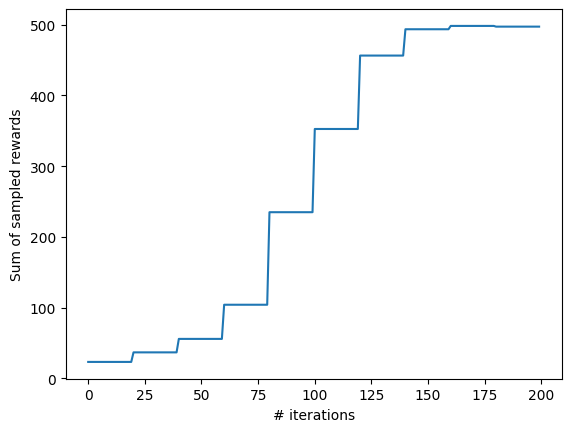

In [185]:
## Plotting
plt.figure()
plt.plot(np.arange(agent.config.n_updates), sum_rewards_track)
plt.xlabel('# iterations')
plt.ylabel('Sum of sampled rewards')